**Тестирование системы верификации диктора на датасете с записями разных годов**

**Цель работы:** оценка качества базовой системы распознавания диктора из лабораторного практикума на собранном датасете с записями разных годов.

**Краткое описание:** в рамках настоящей работы предлагается составить два верификационных протокола тестирования с одинаковым количеством чистой речи в эталонах и тестах (10 секунд), провести тестирование базовой системы распознавания диктора и построить графики зависимости работы модели от возраста диктора.

**Данные:** собранный датасет с записями дикторов разных годов.

**Содержание работы**

1. Подготовка данных и загрузка метаданных.

2. Генерация протоколов верификации:
   - Протокол №1: эталоны и тесты различаются ~5-10 годами записи
   - Протокол №2: эталоны и тесты различаются ~15-20 годами записи

3. Загрузка модели из лабораторной работы №3 (после аугментации).

4. Извлечение дикторских эмбеддингов для эталонных и тестовых записей.

5. Вычисление оценок сравнения и метрики EER.

6. Построение графиков зависимости работы модели от возраста диктора.


In [1]:
# IPython extension to reload modules before executing user code
%load_ext autoreload
%autoreload 2

# Import of modules
import os
import sys

sys.path.append(os.path.realpath('..'))

import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

np.float = float

# Импорт модулей из test_dataset
from protocol_generator import (
    load_metadata, scan_dataset, generate_protocol, save_protocol, load_protocol
)
from evaluation import (
    evaluate_protocol, plot_age_analysis,
    extract_embeddings_for_protocol, compute_protocol_scores,
    evaluate_speaker_protocol, evaluate_speaker_protocol_all_newer, plot_protocol_results,
    plot_protocol3_heatmap
)

# Импорт модели из lab4
from lab4.LoadModel import load_model_from_lab3
from lab4.ResNetFromLab3 import MainModel


**1. Подготовка данных и загрузка метаданных**

В ходе выполнения работы необходимы данные из собранного датасета. Датасет должен иметь структуру:
- Папки с id дикторов (например, id00120, id00121)
- Внутри каждой папки подпапки с годами записи (например, 2005, 2009, 2015)
- В каждой подпапке года находятся wav файлы
- CSV файл с метаданными дикторов (id, имя, пол, дата рождения, язык и т.д.)

Ниже необходимо указать пути к датасету и CSV файлу с метаданными.


In [2]:
# Пути к данным
dataset_path = '/home/danya/datasets/Dataset_Speaker_Rec'
csv_path = '/home/danya/datasets/Dataset_Speaker_Rec/Каталог личностей для доп. задания №2 (2025) - Каталог личностей.csv'
model_path = '../data/lab3_models_aug'  # Путь к модели из lab3 после аугментации
output_dir = './results'  # Директория для сохранения результатов

# Создаем выходную директорию
os.makedirs(output_dir, exist_ok=True)

# Загружаем метаданные
print("Loading metadata...")
metadata = load_metadata(csv_path)
print(f"Loaded metadata for {len(metadata)} speakers")

# Сканируем структуру датасета
print("\nScanning dataset structure...")
dataset_structure = scan_dataset(dataset_path)
print(f"Found {len(dataset_structure)} speakers with recordings")

# Выводим статистику
total_recordings = sum(len(recordings) for recordings in dataset_structure.values())
print(f"Total recordings: {total_recordings}")

# Выводим примеры структуры
print("\nExample speakers:")
for i, (speaker_id, recordings) in enumerate(list(dataset_structure.items())[:5]):
    years = [r[0] for r in recordings]
    print(f"  {speaker_id}: {len(recordings)} recordings in years {min(years)}-{max(years)}")


Loading metadata...
Loaded metadata for 121 speakers

Scanning dataset structure...
Found 120 speakers with recordings
Total recordings: 613

Example speakers:
  id00066: 5 recordings in years 2006-2025
  id00004: 5 recordings in years 2005-2025
  id00055: 5 recordings in years 2002-2025
  id00022: 5 recordings in years 2008-2025
  id00040: 5 recordings in years 1975-1993


**2. Генерация протоколов верификации**

Составляем два верификационных протокола тестирования с одинаковым количеством чистой речи в эталонах и тестах (10 секунд):

1. **Протокол №1**: эталоны и тесты для таргет-попыток различаются ~5-10 годами записи
2. **Протокол №2**: эталоны и тесты для таргет-попыток различаются ~15-20 годами записи

Каждый протокол содержит:
- Таргет-попытки (target trials): сравнения записей одного и того же диктора с разницей в годах
- Импостор-попытки (impostor trials): сравнения записей разных дикторов


In [3]:
# Генерируем Протокол №1 (5-10 лет разница)
print("Generating Protocol 1 (5-10 years difference)...")
protocol1 = generate_protocol(
    dataset_structure,
    metadata,
    min_year_diff=5,
    max_year_diff=10,
    num_target_trials=None,  # Используем все возможные
    num_impostor_trials=None  # Используем все возможные
)
protocol1_path = os.path.join(output_dir, 'protocol1.txt')
save_protocol(protocol1, protocol1_path)
print(f"Protocol 1: {len(protocol1)} trials")
print(f"  Target trials: {sum(1 for p in protocol1 if p[0] == 1)}")
print(f"  Impostor trials: {sum(1 for p in protocol1 if p[0] == 0)}")


Generating Protocol 1 (5-10 years difference)...
Protocol 1: 1256 trials
  Target trials: 630
  Impostor trials: 626


In [4]:
# Генерируем Протокол №2 (15-20 лет разница)
print("Generating Protocol 2 (15-20 years difference)...")
protocol2 = generate_protocol(
    dataset_structure,
    metadata,
    min_year_diff=15,
    max_year_diff=20,
    num_target_trials=None,
    num_impostor_trials=None
)
protocol2_path = os.path.join(output_dir, 'protocol2.txt')
save_protocol(protocol2, protocol2_path)
print(f"Protocol 2: {len(protocol2)} trials")
print(f"  Target trials: {sum(1 for p in protocol2 if p[0] == 1)}")
print(f"  Impostor trials: {sum(1 for p in protocol2 if p[0] == 0)}")


Generating Protocol 2 (15-20 years difference)...
Protocol 2: 512 trials
  Target trials: 258
  Impostor trials: 254


**3. Загрузка модели из лабораторной работы №3**

Загружаем обученную модель из лабораторной работы №3 (после аугментации данных). Модель используется для извлечения дикторских эмбеддингов.


In [5]:
# Параметры модели (должны совпадать с параметрами из lab3)
nOut = 512
encoder_type = 'SP'
n_mels = 40
log_input = True

# Создаем модель
print("Initializing model...")
model = MainModel(nOut=nOut, encoder_type=encoder_type, n_mels=n_mels, log_input=log_input)

# Загружаем веса из lab3
print(f"Loading model from {model_path}...")
model = load_model_from_lab3(model, model_path=model_path, epoch=None)

# Переводим модель в режим оценки и на GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)
model.eval()
print(f"Model loaded successfully on {device}")


Initializing model...
Embedding size is 512, encoder SP.
Loading model from ../data/lab3_models_aug...
Loading latest model: lab3_model_0039.pth
Loaded model from: lab3_model_0039.pth
Trained for 39 epochs
Model loaded successfully on cuda


**4. Оценка Протокола №1 (5-10 лет разница)**

Извлекаем дикторские эмбеддинги для всех записей в протоколе, вычисляем скоры сравнения и метрику EER.


In [6]:
# Параметры для извлечения эмбеддингов
eval_frames = 200  # ~10 секунд при hop_length=160

print("="*60)
print("Evaluating Protocol 1 (5-10 years difference)")
print("="*60)

eer1, scores1, labels1, trials_info1 = evaluate_protocol(
    model,
    protocol1_path,
    dataset_path,
    eval_frames=eval_frames,
    device=device,
    metadata=metadata
)


Evaluating Protocol 1 (5-10 years difference)
Loaded protocol with 1256 trials
Extracting embeddings...


/home/danya/develop/sr_labs_book/lab4/ResNetFromLab3.py:192: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00063/2010/00063.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00063/2010/00063.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00063/2020/00063.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00063/2020/00063.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00063/2025/00063.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00063/2025/00063.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00066/2006/00066.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00066/2006/00066.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00066/2010/00066.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00066/2010/00066.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/

**5. Оценка Протокола №2 (15-20 лет разница)**

Извлекаем дикторские эмбеддинги для всех записей в протоколе, вычисляем скоры сравнения и метрику EER.


In [7]:
print("="*60)
print("Evaluating Protocol 2 (15-20 years difference)")
print("="*60)

eer2, scores2, labels2, trials_info2 = evaluate_protocol(
    model,
    protocol2_path,
    dataset_path,
    eval_frames=eval_frames,
    device=device,
    metadata=metadata
)


Evaluating Protocol 2 (15-20 years difference)
Loaded protocol with 512 trials
Extracting embeddings...


/home/danya/develop/sr_labs_book/lab4/ResNetFromLab3.py:192: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00063/2010/00063.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00063/2010/00063.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00063/2020/00063.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00063/2020/00063.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00063/2025/00063.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00063/2025/00063.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00066/2006/00066.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00066/2006/00066.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00066/2010/00066.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00066/2010/00066.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/

**6. Построение графиков зависимости работы модели от возраста диктора**

Строим графики для анализа зависимости качества работы модели от разницы лет между записями эталона и теста.


In [8]:
# Графики для Протокола №1
print("\nGenerating plots for Protocol 1...")
plot_age_analysis(
    scores1, labels1, trials_info1, metadata,
    "Protocol 1 (5-10 years)",
    os.path.join(output_dir, 'protocol1_analysis.png')
)



Generating plots for Protocol 1...
Saved plot to ./results/protocol1_analysis.png


In [9]:
# Графики для Протокола №2
print("Generating plots for Protocol 2...")
plot_age_analysis(
    scores2, labels2, trials_info2, metadata,
    "Protocol 2 (15-20 years)",
    os.path.join(output_dir, 'protocol2_analysis.png')
)


Generating plots for Protocol 2...
Saved plot to ./results/protocol2_analysis.png


**7. Итоговые результаты**

Выводим сводку результатов тестирования для обоих протоколов.


In [10]:
# Сохраняем результаты в файл
results_path = os.path.join(output_dir, 'results.txt')
with open(results_path, 'w', encoding='utf-8') as f:
    f.write("Speaker Verification Evaluation Results\n")
    f.write("="*60 + "\n\n")
    f.write(f"Protocol 1 (5-10 years difference):\n")
    f.write(f"  EER: {eer1:.2f}%\n")
    f.write(f"  Target trials: {np.sum(labels1 == 1)}\n")
    f.write(f"  Impostor trials: {np.sum(labels1 == 0)}\n\n")
    f.write(f"Protocol 2 (15-20 years difference):\n")
    f.write(f"  EER: {eer2:.2f}%\n")
    f.write(f"  Target trials: {np.sum(labels2 == 1)}\n")
    f.write(f"  Impostor trials: {np.sum(labels2 == 0)}\n\n")

# Выводим результаты
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Protocol 1 (5-10 years) EER: {eer1:.2f}%")
print(f"Protocol 2 (15-20 years) EER: {eer2:.2f}%")
print("="*60)
print(f"\nResults saved to {results_path}")
print(f"Plots saved to:")
print(f"  - {os.path.join(output_dir, 'protocol1_analysis.png')}")
print(f"  - {os.path.join(output_dir, 'protocol2_analysis.png')}")



SUMMARY
Protocol 1 (5-10 years) EER: 10.15%
Protocol 2 (15-20 years) EER: 12.13%

Results saved to ./results/results.txt
Plots saved to:
  - ./results/protocol1_analysis.png
  - ./results/protocol2_analysis.png


Protocol 1 Analysis:


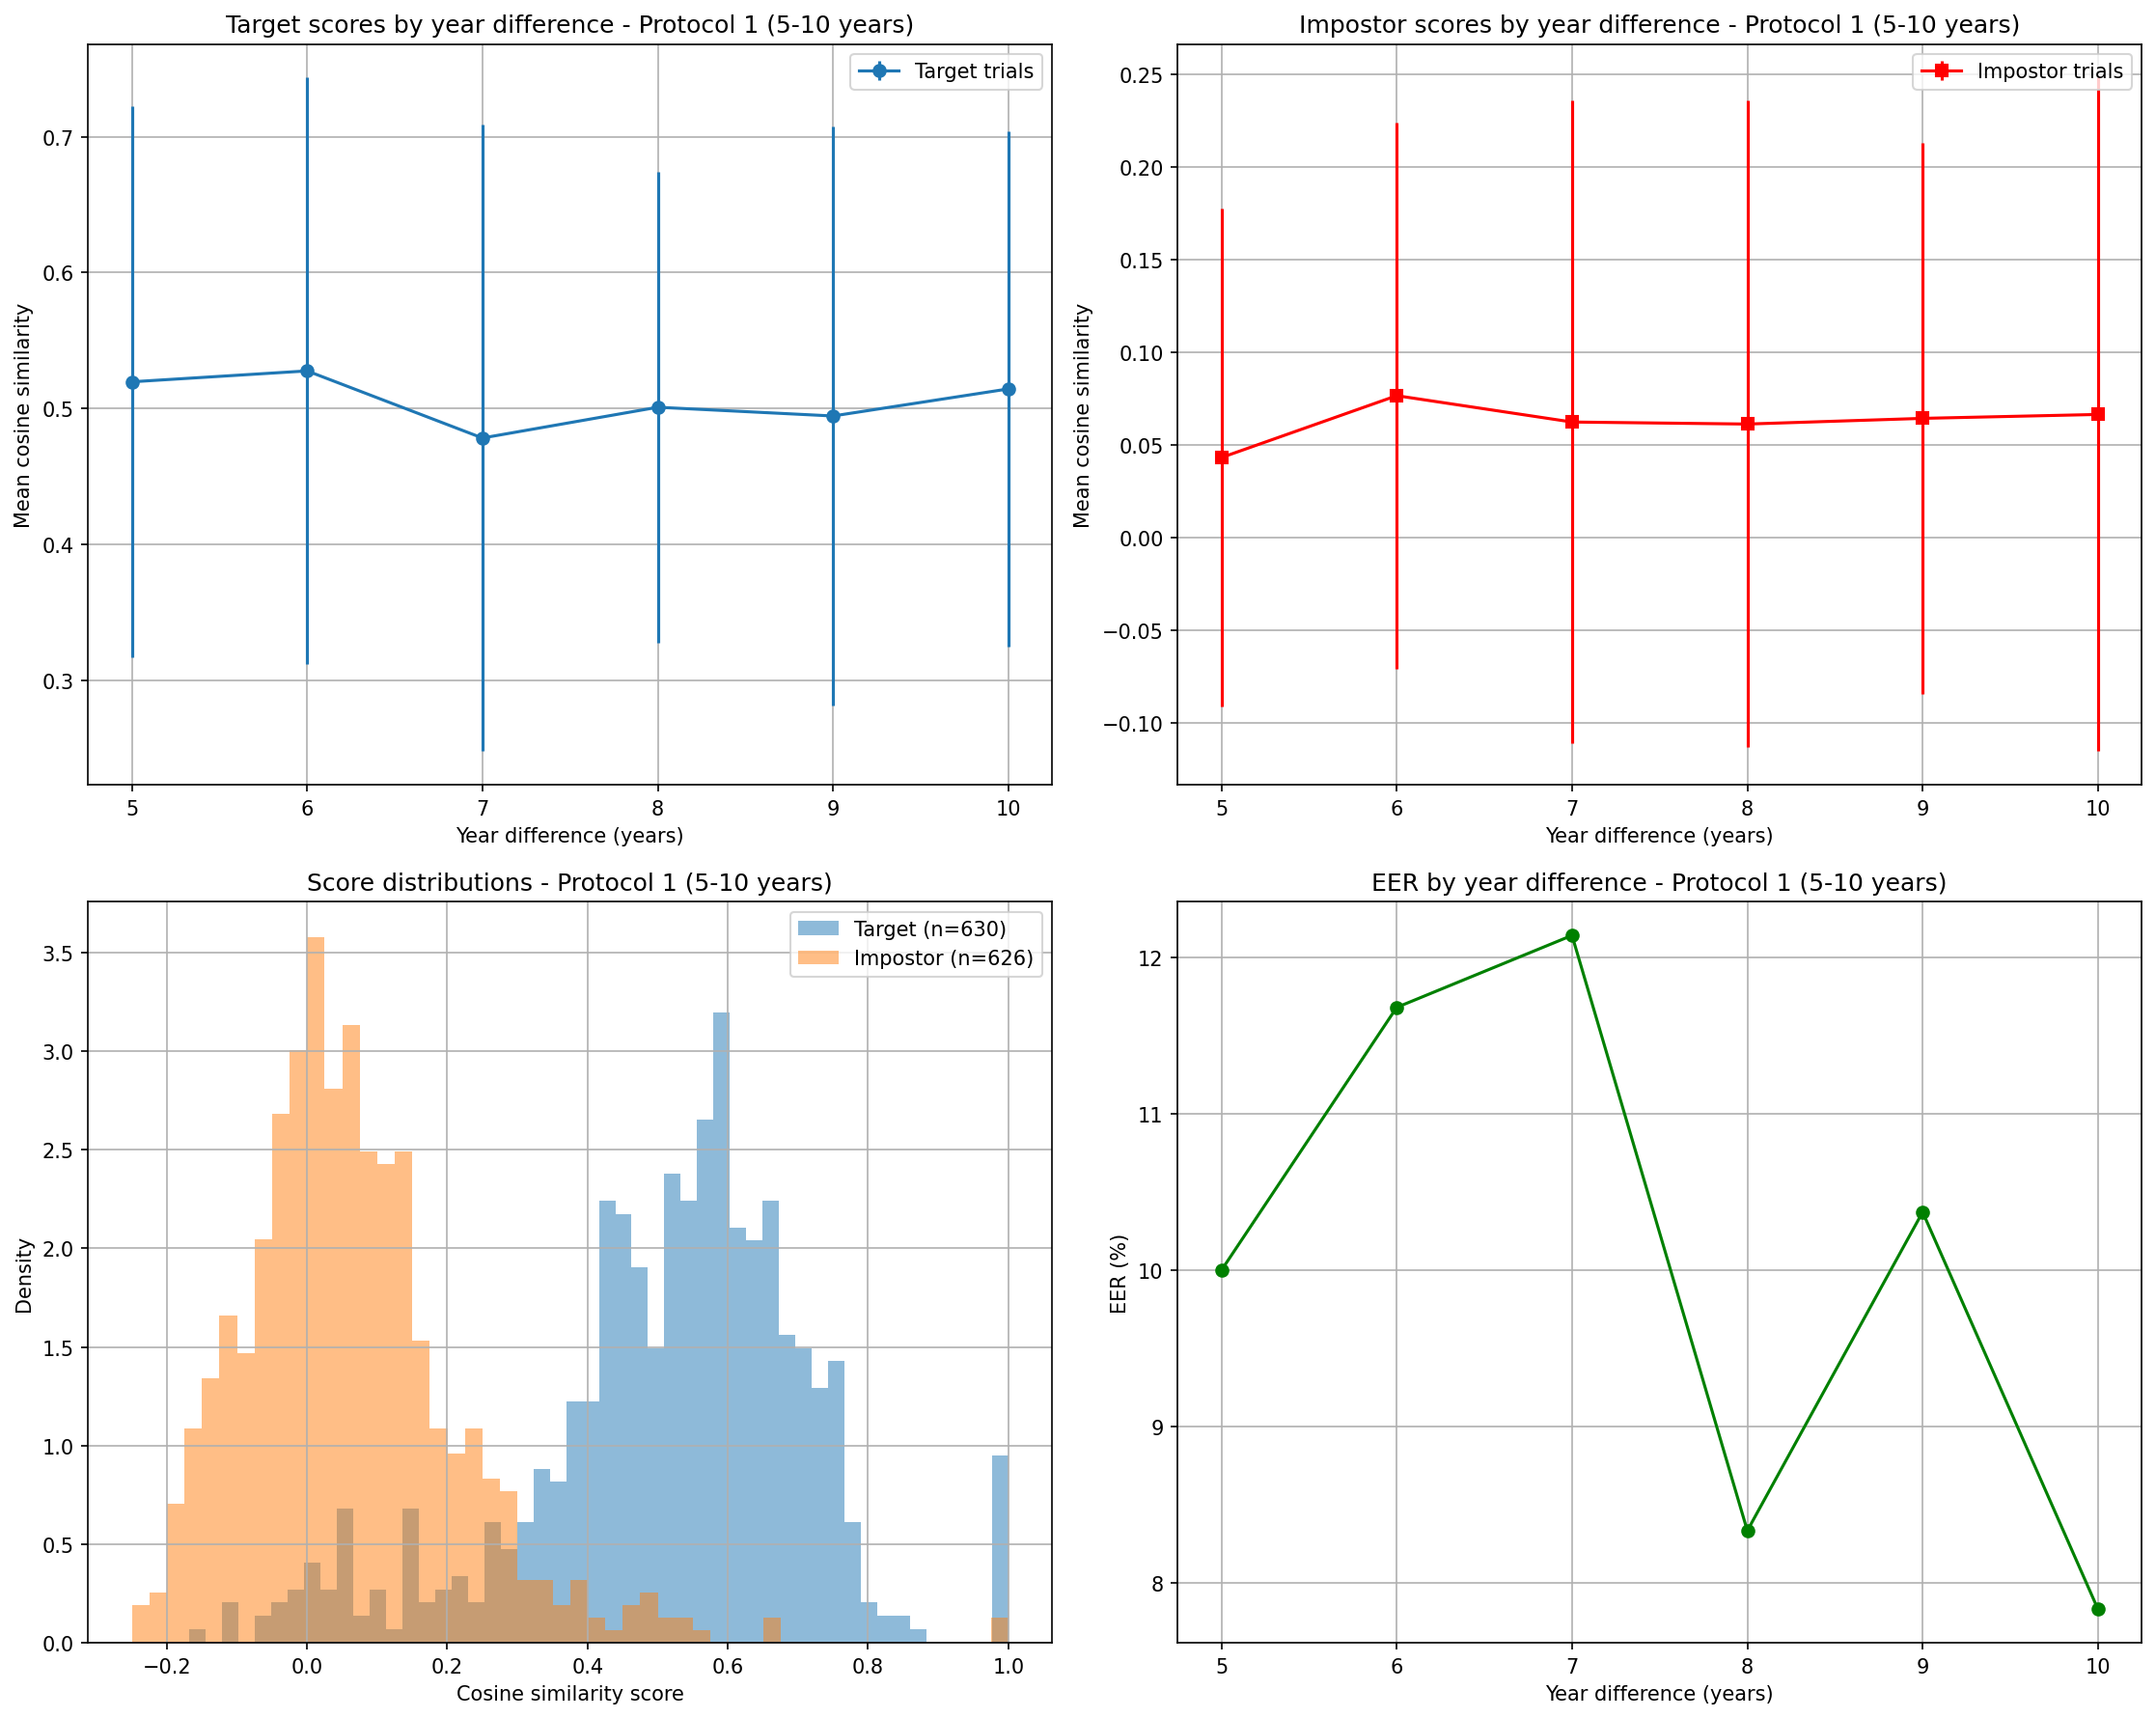


Protocol 2 Analysis:


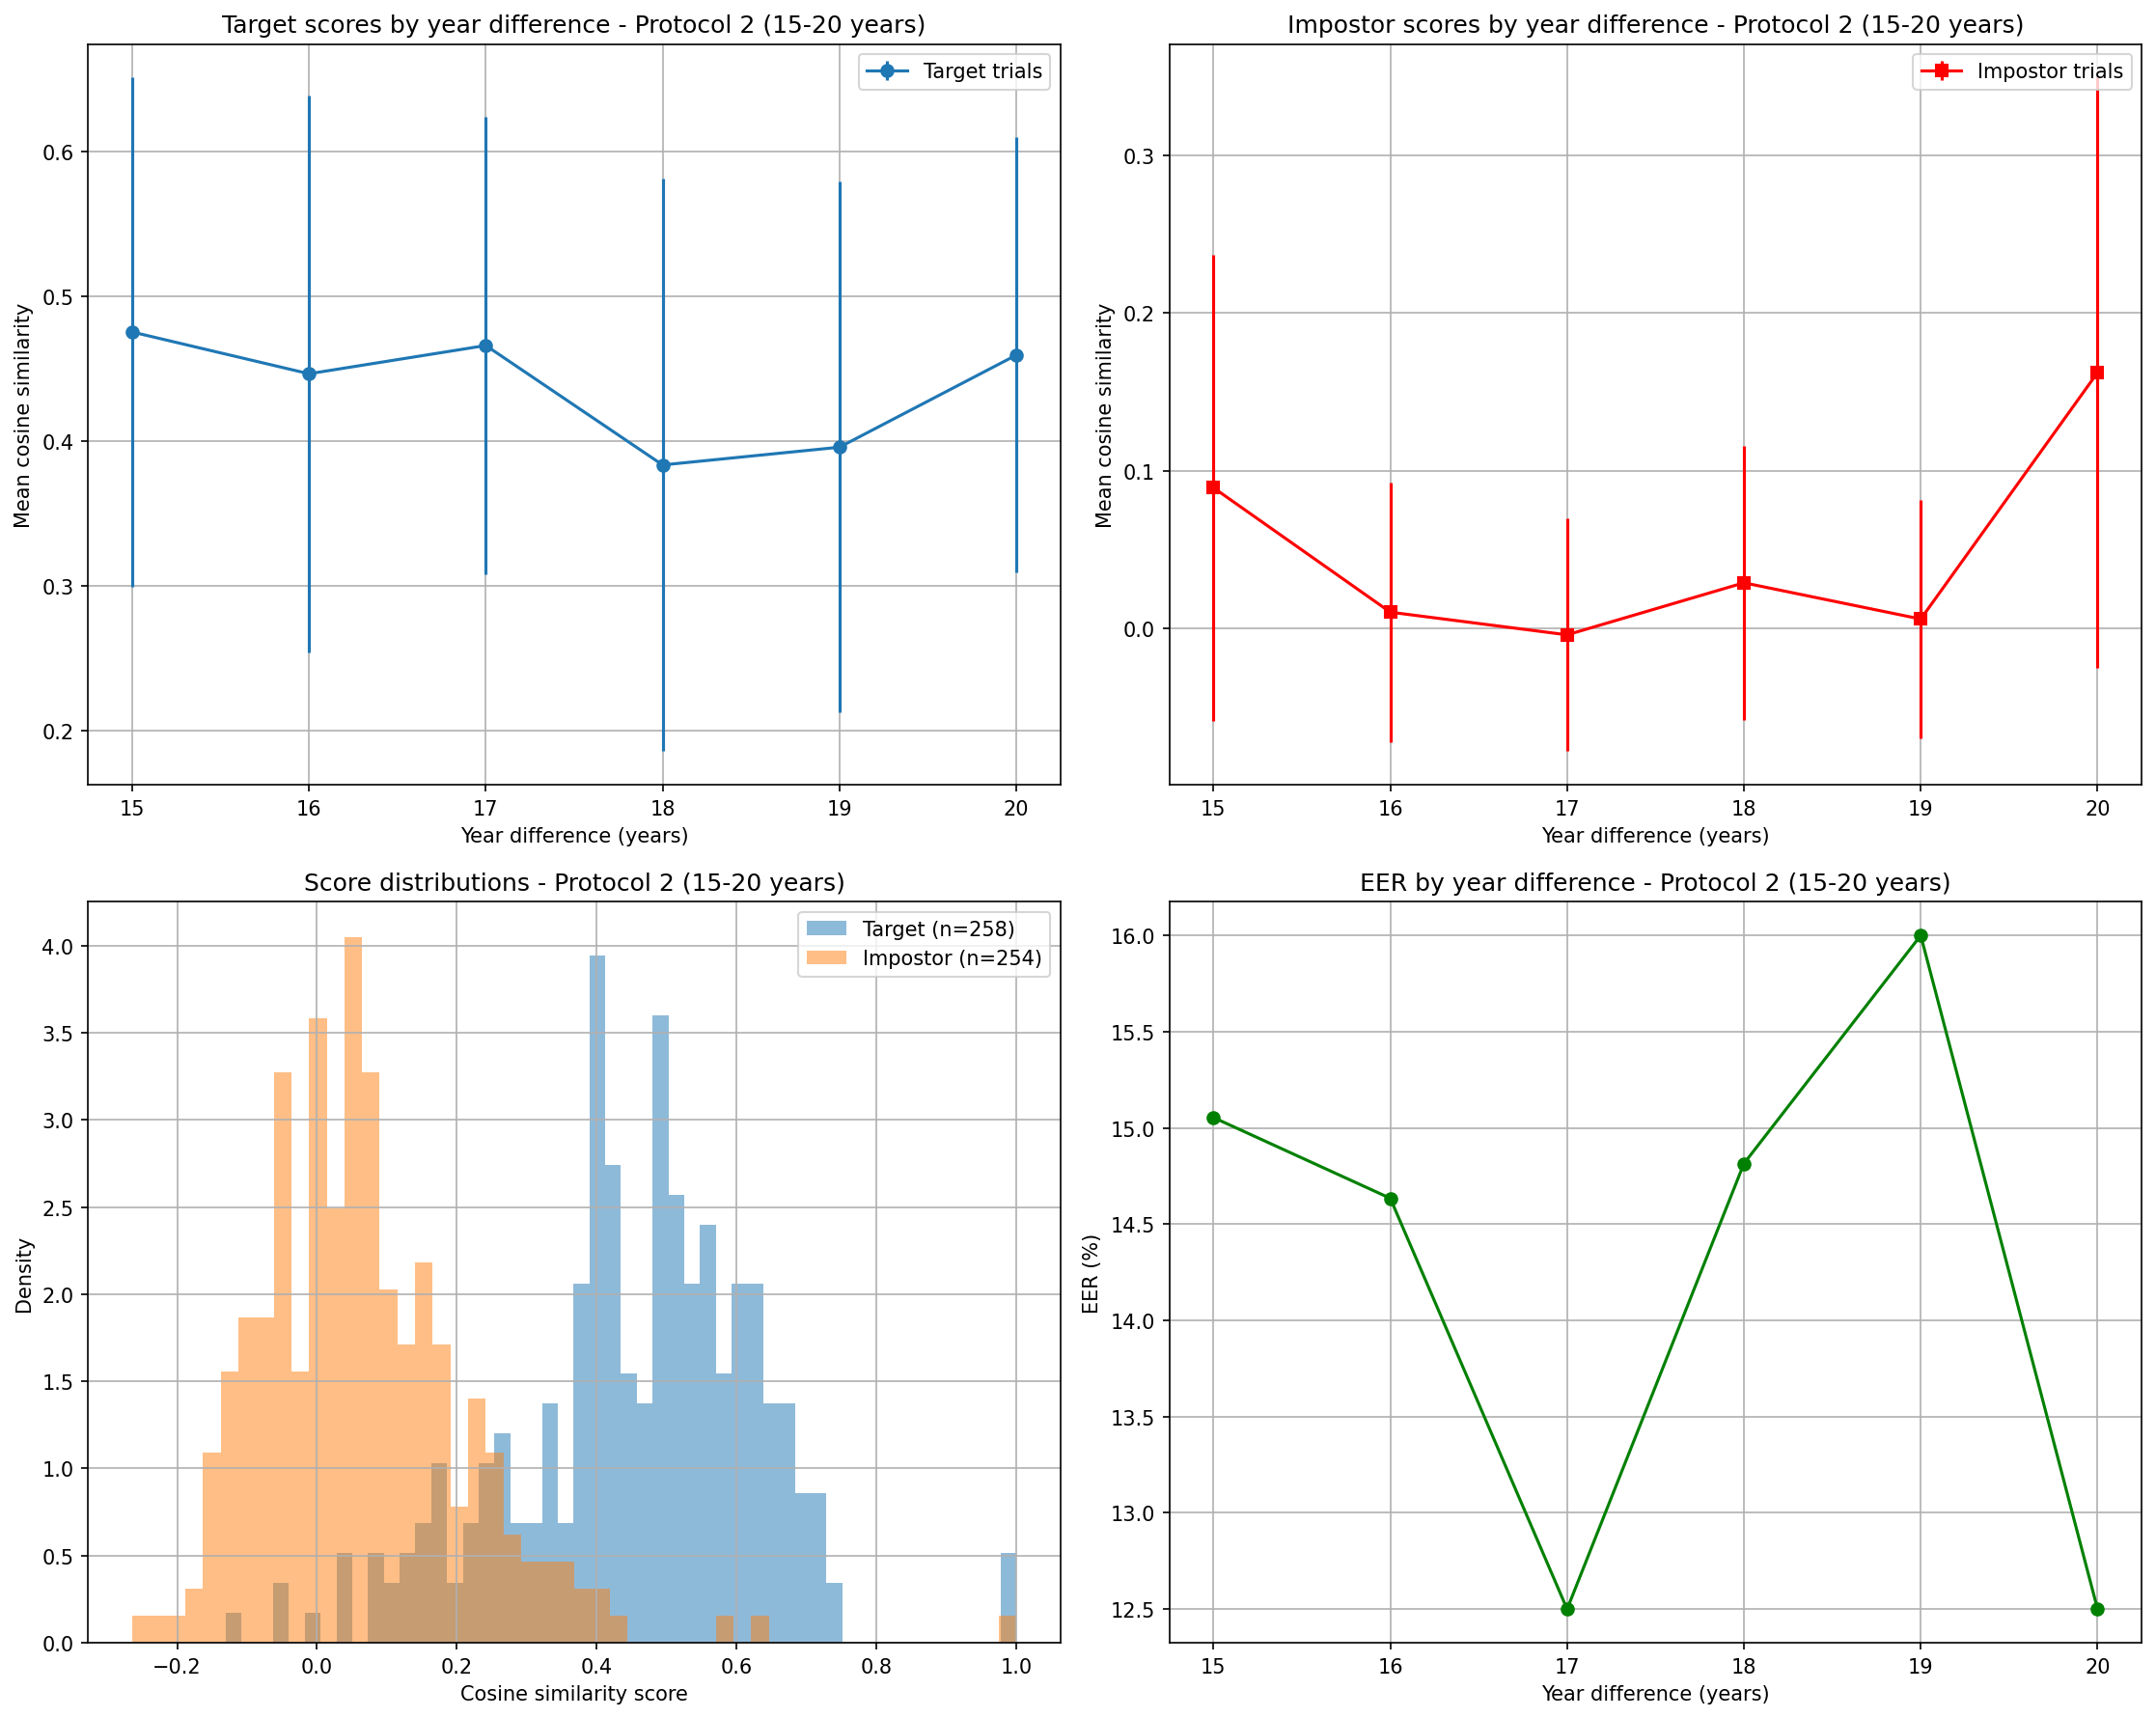

In [11]:
# Отображаем графики прямо в notebook
from IPython.display import Image, display

print("Protocol 1 Analysis:")
display(Image(os.path.join(output_dir, 'protocol1_analysis.png')))

print("\nProtocol 2 Analysis:")
display(Image(os.path.join(output_dir, 'protocol2_analysis.png')))


**7. Новые протоколы для индивидуальной оценки дикторов**

Протокол 1: Для каждого диктора берется самая старая запись как эталон и сравнивается с более новыми записями с разницей 5-10 лет.

Протокол 2: Аналогично протоколу 1, но разница 15-20 лет.

Протокол 3: Для каждого диктора берется самая старая запись как эталон и сравнивается со всеми более новыми записями.


In [12]:
# Протокол 1: Разница 5-10 лет
print("=" * 80)
print("PROTOCOL 1: Year difference 5-10 years")
print("=" * 80)

results1 = evaluate_speaker_protocol(
    model,
    dataset_path,
    metadata,
    min_year_diff=5,
    max_year_diff=10,
    eval_frames=eval_frames,
    device=device,
    output_file=os.path.join(output_dir, 'protocol1_individual_results.csv')
)

print(f"\nProtocol 1: Processed {len(results1)} speaker pairs")


PROTOCOL 1: Year difference 5-10 years
Found 120 speakers in dataset
Speakers with matching recordings: 89
Extracting embeddings for all recordings...
Total unique files to process: 217


/home/danya/develop/sr_labs_book/lab4/ResNetFromLab3.py:192: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00077/2003/00077.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00077/2003/00077.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00071/2007/00071.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00071/2007/00071.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00063/2010/00063.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00063/2010/00063.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00077/2010/00077.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00077/2010/00077.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00072/2005/00072.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00072/2005/00072.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/

In [13]:
# Протокол 2: Разница 15-20 лет
print("=" * 80)
print("PROTOCOL 2: Year difference 15-20 years")
print("=" * 80)

results2 = evaluate_speaker_protocol(
    model,
    dataset_path,
    metadata,
    min_year_diff=15,
    max_year_diff=20,
    eval_frames=eval_frames,
    device=device,
    output_file=os.path.join(output_dir, 'protocol2_individual_results.csv')
)

print(f"\nProtocol 2: Processed {len(results2)} speaker pairs")


PROTOCOL 2: Year difference 15-20 years
Found 120 speakers in dataset
Speakers with matching recordings: 91
Extracting embeddings for all recordings...
Total unique files to process: 217


/home/danya/develop/sr_labs_book/lab4/ResNetFromLab3.py:192: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00077/2003/00077.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00077/2003/00077.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00063/2025/00063.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00063/2025/00063.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00070/1995/00070.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00070/1995/00070.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00079/2024/00079.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00079/2024/00079.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00071/2018/00071.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00071/2018/00071.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/

In [14]:
# Протокол 3: Все более новые записи
print("=" * 80)
print("PROTOCOL 3: All newer recordings")
print("=" * 80)

results3 = evaluate_speaker_protocol_all_newer(
    model,
    dataset_path,
    metadata,
    eval_frames=eval_frames,
    device=device,
    output_file=os.path.join(output_dir, 'protocol3_individual_results.csv')
)

print(f"\nProtocol 3: Processed {len(results3)} speaker pairs")


PROTOCOL 3: All newer recordings
Found 120 speakers in dataset
Speakers with at least 2 recordings: 92
Extracting embeddings for all recordings...
Total unique files to process: 462


/home/danya/develop/sr_labs_book/lab4/ResNetFromLab3.py:192: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00077/2003/00077.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00077/2003/00077.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00077/2015/00077.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00077/2015/00077.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00077/2010/00077.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00077/2010/00077.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00080/2010/00080.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00080/2010/00080.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/id00070/2006/00070.wav: Error opening '/home/danya/datasets/Dataset_Speaker_Rec/id00070/2006/00070.wav': Format not recognised.
Error reading file /home/danya/datasets/Dataset_Speaker_Rec/

In [15]:
# Построение графиков для протокола 1
print("\nGenerating plots for Protocol 1...")
plot_protocol_results(
    os.path.join(output_dir, 'protocol1_individual_results.csv'),
    os.path.join(output_dir, 'protocol1_individual_plots.png'),
    protocol_name="Protocol 1 (5-10 years)"
)



Generating plots for Protocol 1...


In [16]:
# Построение графиков для протокола 2
print("\nGenerating plots for Protocol 2...")
plot_protocol_results(
    os.path.join(output_dir, 'protocol2_individual_results.csv'),
    os.path.join(output_dir, 'protocol2_individual_plots.png'),
    protocol_name="Protocol 2 (15-20 years)"
)



Generating plots for Protocol 2...


In [17]:
# Тепловая карта для протокола 3: вероятность того же диктора
print("\nGenerating heatmap for Protocol 3...")
plot_protocol3_heatmap(
    os.path.join(output_dir, 'protocol3_individual_results.csv'),
    os.path.join(output_dir, 'protocol3_heatmap.png')
)



Generating heatmap for Protocol 3...
Data points for heatmap: 336
Saved heatmap to ./results/protocol3_heatmap.png


In [18]:
# Построение графиков для протокола 3
print("\nGenerating plots for Protocol 3...")
plot_protocol_results(
    os.path.join(output_dir, 'protocol3_individual_results.csv'),
    os.path.join(output_dir, 'protocol3_individual_plots.png'),
    protocol_name="Protocol 3 (All newer recordings)"
)



Generating plots for Protocol 3...
Saved plots to ./results/protocol3_individual_plots.png



Protocol 1 Individual Results:
Protocol 1 plots not generated

Protocol 2 Individual Results:
Protocol 2 plots not generated

Protocol 3 Individual Results:


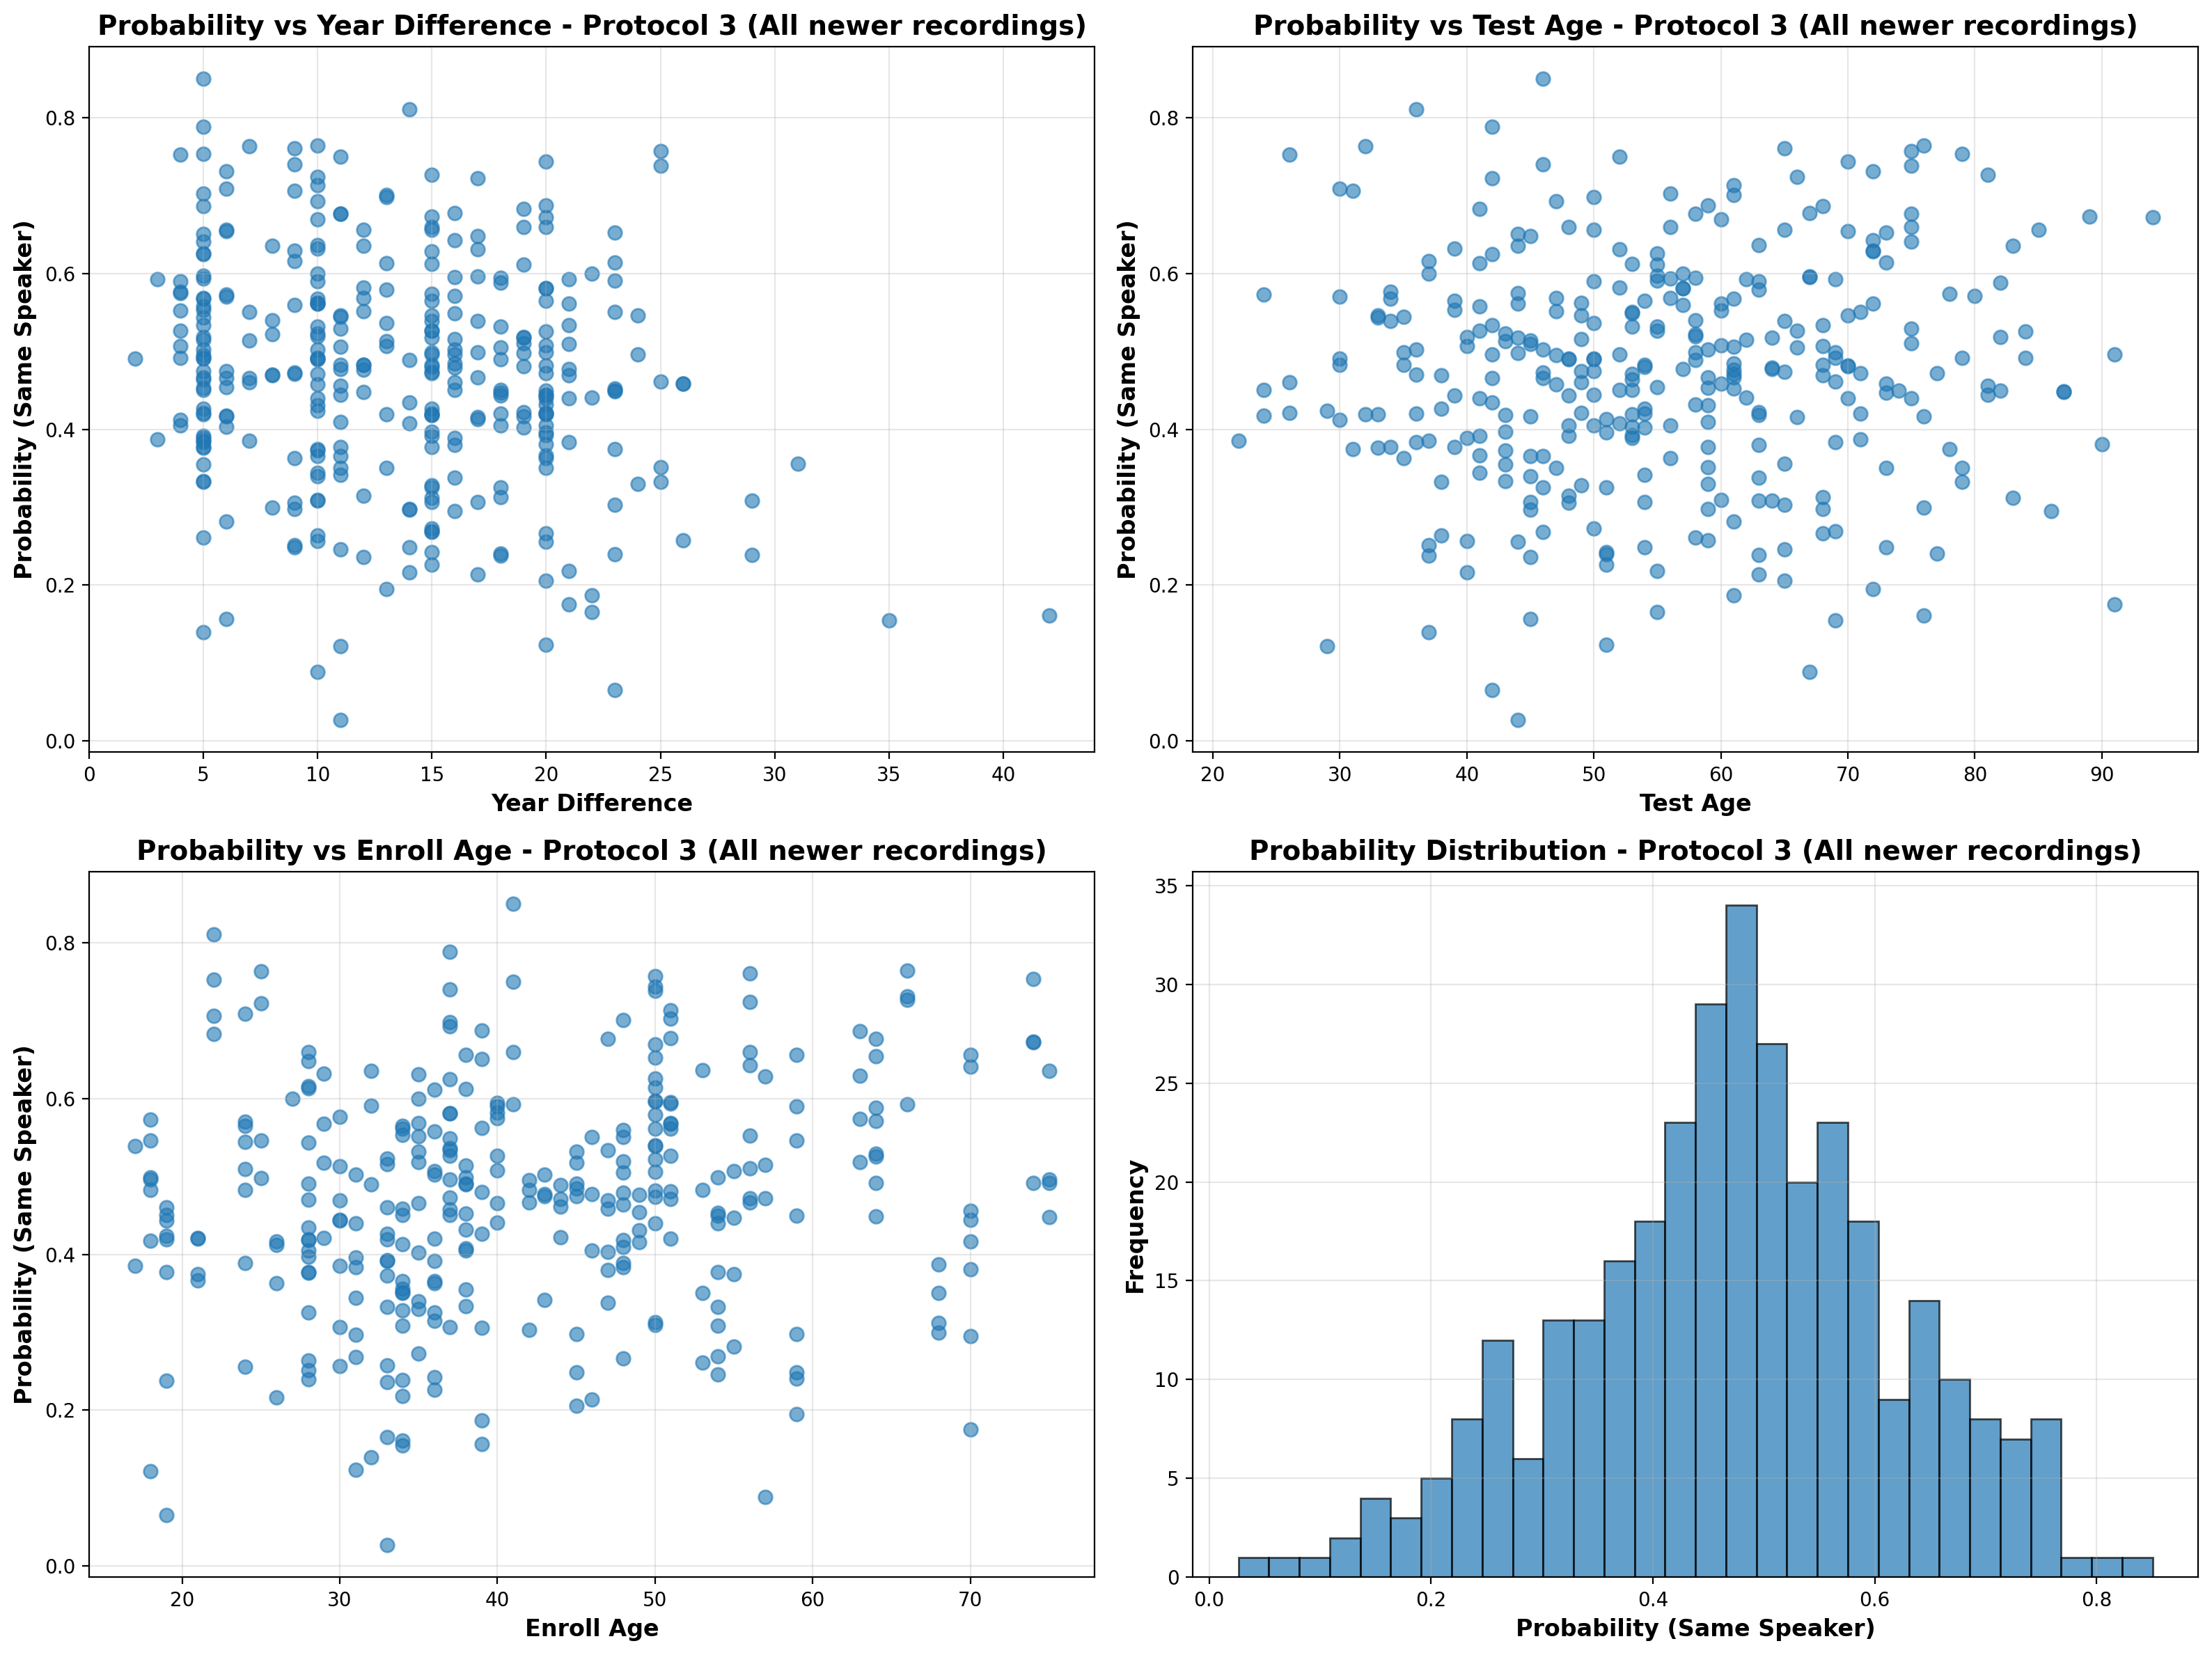

In [19]:
# Отображение графиков
from IPython.display import Image, display

print("\nProtocol 1 Individual Results:")
if os.path.exists(os.path.join(output_dir, 'protocol1_individual_plots.png')):
    display(Image(os.path.join(output_dir, 'protocol1_individual_plots.png')))
else:
    print("Protocol 1 plots not generated")

print("\nProtocol 2 Individual Results:")
if os.path.exists(os.path.join(output_dir, 'protocol2_individual_plots.png')):
    display(Image(os.path.join(output_dir, 'protocol2_individual_plots.png')))
else:
    print("Protocol 2 plots not generated")

print("\nProtocol 3 Individual Results:")
if os.path.exists(os.path.join(output_dir, 'protocol3_individual_plots.png')):
    display(Image(os.path.join(output_dir, 'protocol3_individual_plots.png')))
else:
    print("Protocol 3 plots not generated")


**Дополнительный анализ**

Сравнение распределений скоров для таргет и импостор попыток в обоих протоколах.


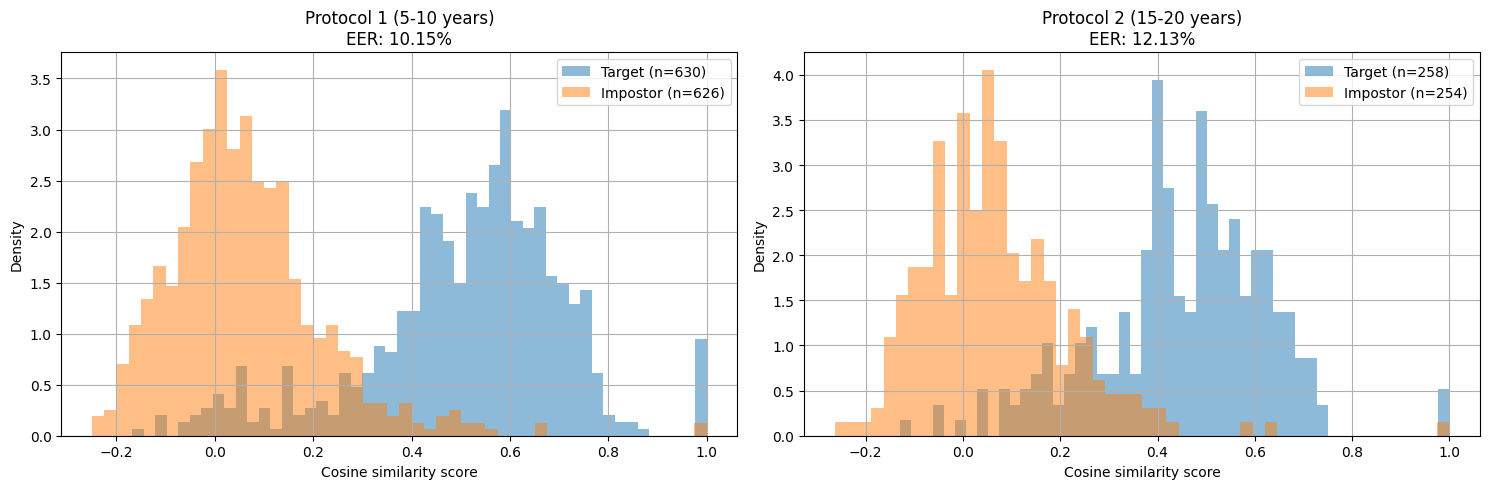


Comparison plot saved to ./results/protocols_comparison.png


In [20]:
# Дополнительная визуализация: сравнение протоколов
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Протокол 1
ax1 = axes[0]
target_scores1 = scores1[labels1 == 1]
impostor_scores1 = scores1[labels1 == 0]
ax1.hist(target_scores1, bins=50, alpha=0.5, label=f'Target (n={len(target_scores1)})', density=True)
ax1.hist(impostor_scores1, bins=50, alpha=0.5, label=f'Impostor (n={len(impostor_scores1)})', density=True)
ax1.set_xlabel('Cosine similarity score')
ax1.set_ylabel('Density')
ax1.set_title(f'Protocol 1 (5-10 years)\nEER: {eer1:.2f}%')
ax1.legend()
ax1.grid(True)

# Протокол 2
ax2 = axes[1]
target_scores2 = scores2[labels2 == 1]
impostor_scores2 = scores2[labels2 == 0]
ax2.hist(target_scores2, bins=50, alpha=0.5, label=f'Target (n={len(target_scores2)})', density=True)
ax2.hist(impostor_scores2, bins=50, alpha=0.5, label=f'Impostor (n={len(impostor_scores2)})', density=True)
ax2.set_xlabel('Cosine similarity score')
ax2.set_ylabel('Density')
ax2.set_title(f'Protocol 2 (15-20 years)\nEER: {eer2:.2f}%')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'protocols_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nComparison plot saved to {os.path.join(output_dir, 'protocols_comparison.png')}")


Protocol 3 Heatmap (Probability by Age and Year Difference):


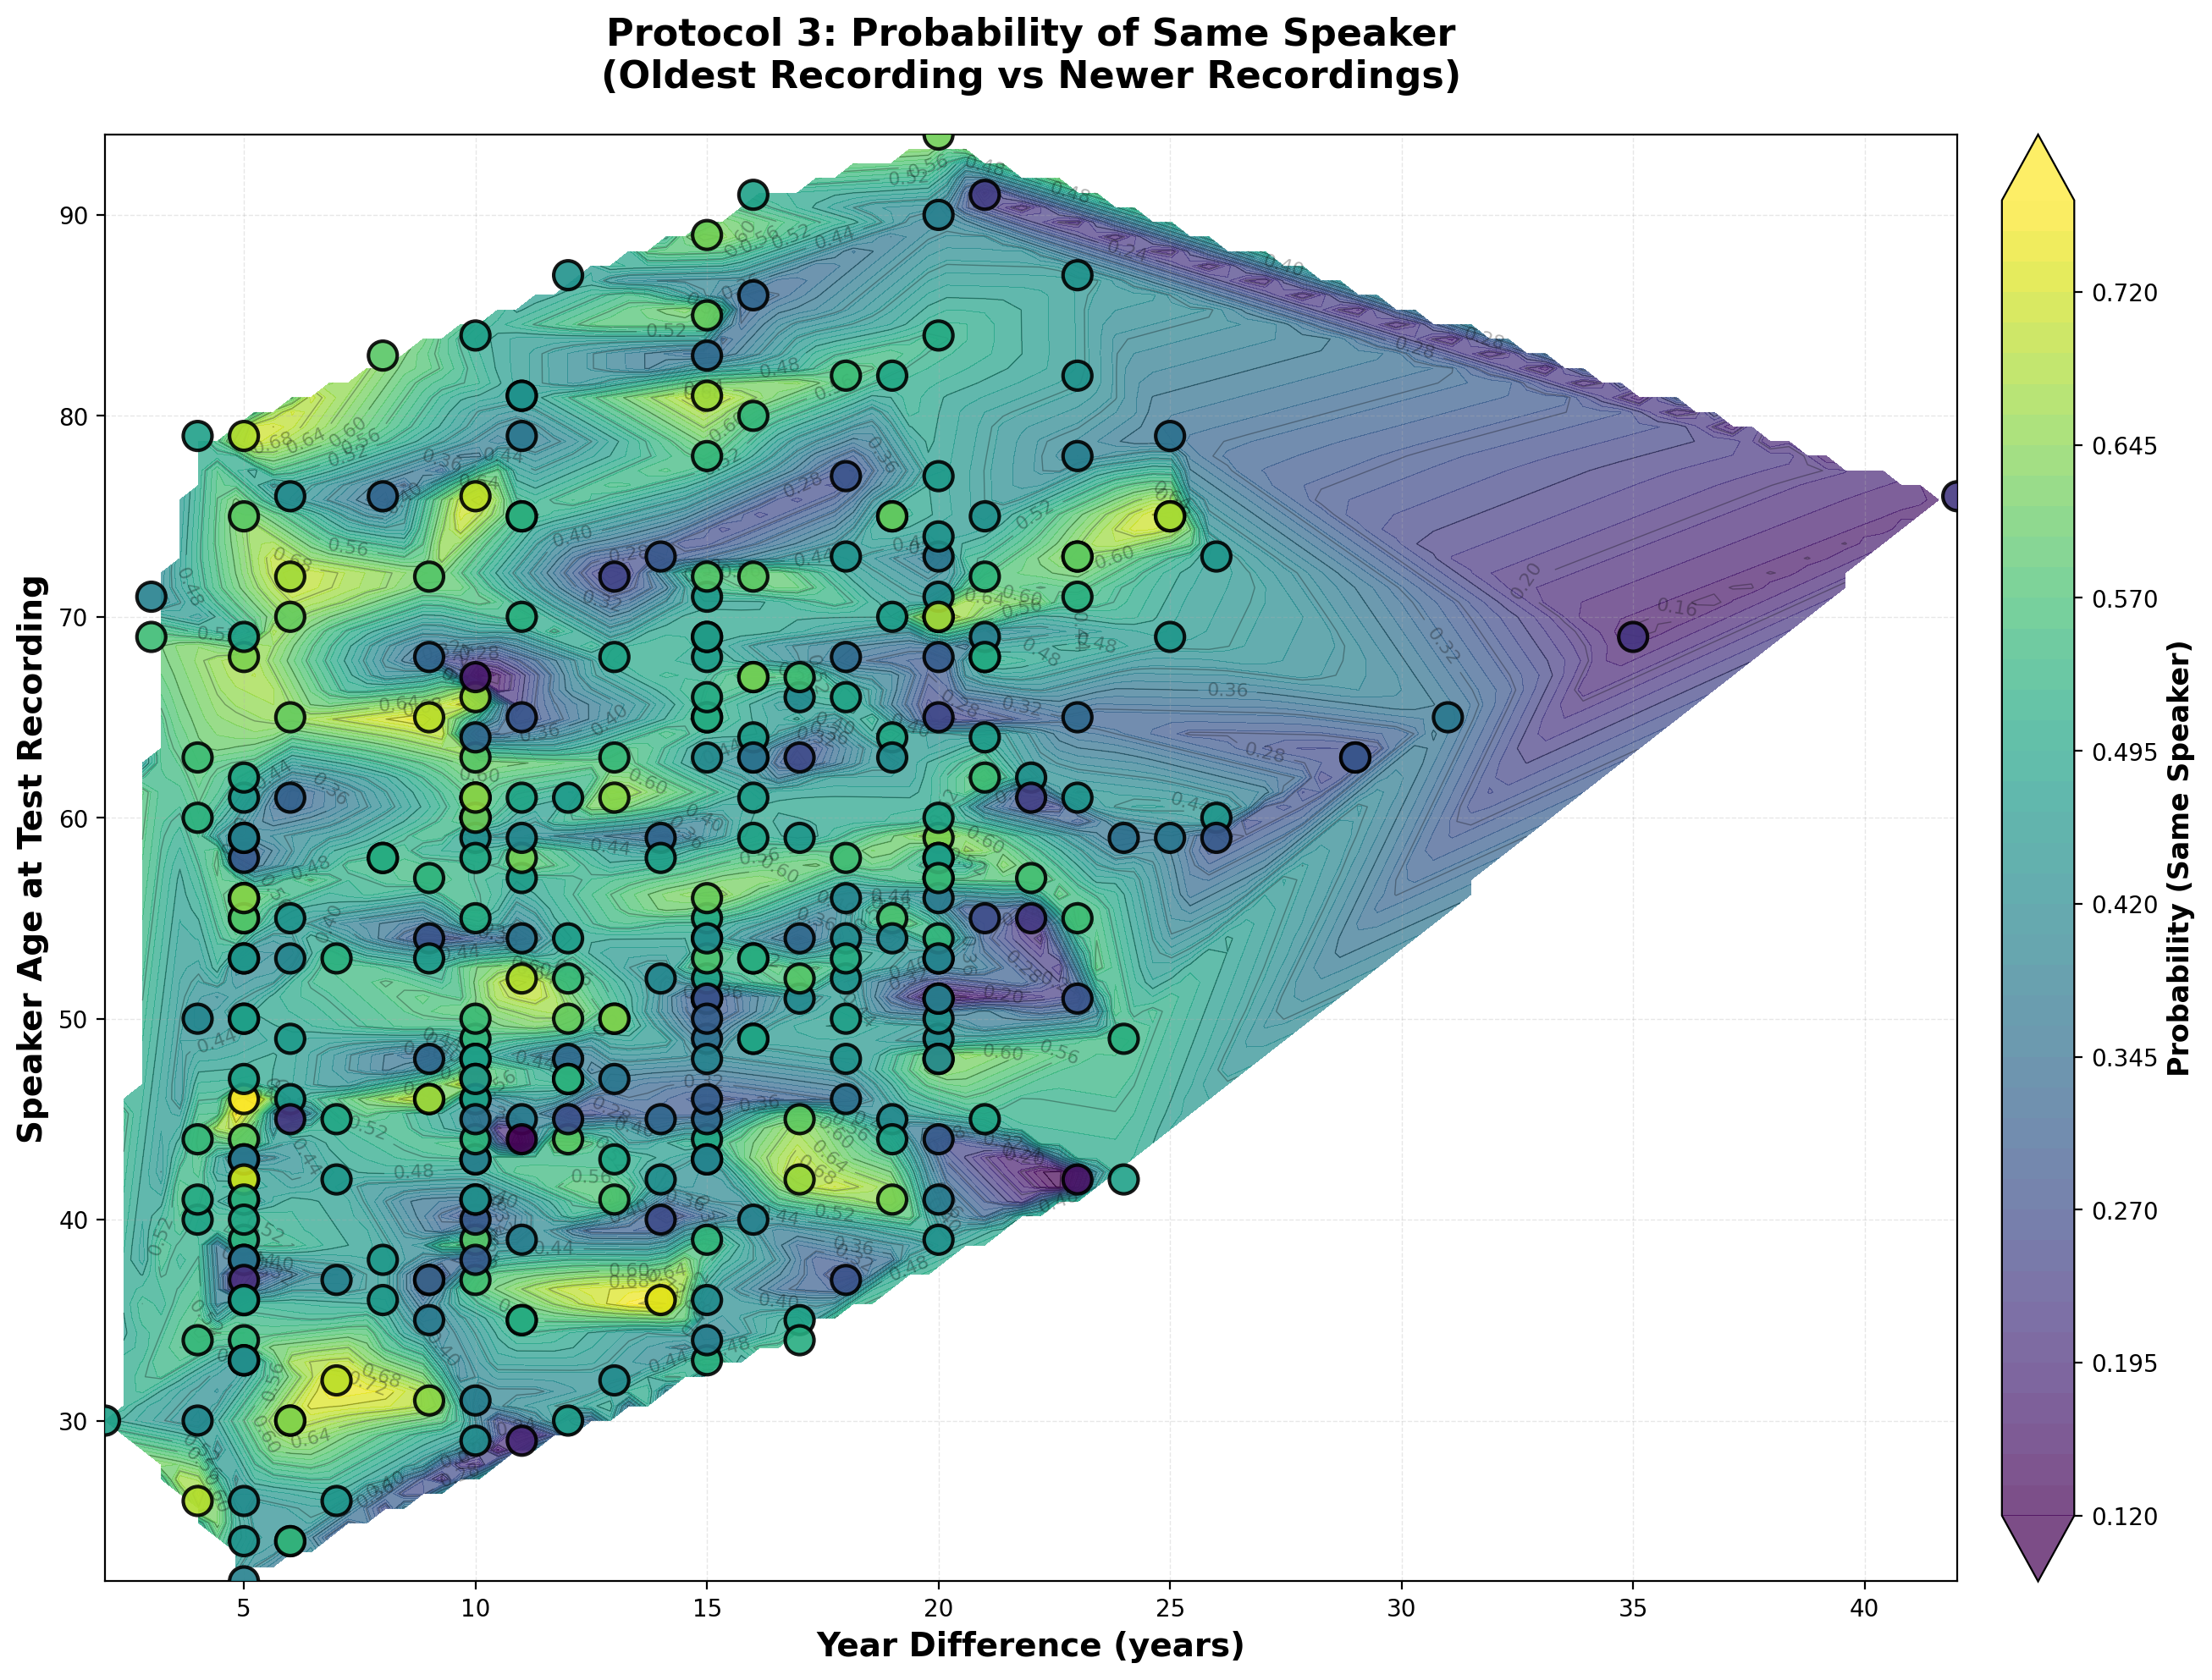

In [21]:
# Тепловая карта протокола 3: вероятность того же диктора
from IPython.display import Image, display

print("Protocol 3 Heatmap (Probability by Age and Year Difference):")
if os.path.exists(os.path.join(output_dir, 'protocol3_heatmap.png')):
    display(Image(os.path.join(output_dir, 'protocol3_heatmap.png')))
else:
    print("Protocol 3 heatmap not generated")
